# 2D Holstein nu=16 RMSD plots

This notebook auto-discovers `*.npz` and `*.xlsx` result files under `multiset_202606/2DHolstein_nu16` and produces eight RMSD figures: five coupling-wise convergence plots and three size-wise G-comparison plots.


In [3]:
from dataclasses import dataclass
from pathlib import Path
from typing import Optional
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import to_hex, to_rgb
from matplotlib.lines import Line2D

# Run this notebook either from the repository root or from multiset_202606/2DHolstein_nu16.
BASE_DIR = Path.cwd()
if BASE_DIR.name != "2DHolstein_nu16":
    candidate = Path("multiset_202606/2DHolstein_nu16")
    BASE_DIR = candidate if candidate.exists() else BASE_DIR

COUPLINGS = ["G0.25", "G0.5", "G1", "G2", "G4"]
METHODS = ["multiset", "singleset"]
TARGET_SIZES = [5, 7, 9]
CONVERGENCE_BOND_DIMS = [16, 32, 64]
TIME_DIVISOR = 2 * np.pi
XLSX_DT_FALLBACK = 0.1

SAVE_FIGURES = False
FIG_DIR = BASE_DIR / "figures"

COUPLING_LABELS = {
    "G0.25": "G = 0.25",
    "G0.5": "G = 0.5",
    "G1": "G = 1",
    "G2": "G = 2",
    "G4": "G = 4",
}

COUPLING_BASE_COLORS = {
    "G0.25": "#286090",
    "G0.5": "#2c7f5b",
    "G1": "#d0832f",
    "G2": "#ba4a48",
    "G4": "#6f5aa8",
}

SIZE_BASE_COLORS = {
    5: "#1f77b4",
    7: "#d62728",
    9: "#2ca02c",
}

@dataclass(frozen=True)
class RunMeta:
    coupling: str
    size: int
    method: str
    bond_dim: Optional[int]
    path: Path

@dataclass
class RunData:
    meta: RunMeta
    time: Optional[np.ndarray] = None
    occupations: Optional[np.ndarray] = None

BASE_DIR


PosixPath('/curie-home/zengjj/Renormalizer/multiset_202606/2DHolstein_nu16')

In [4]:
def parse_square_size_token(token):
    for split in range(1, len(token)):
        left = token[:split]
        right = token[split:]
        if left and right and int(left) == int(right):
            return int(left)
    return None

def parse_square_size(path: Path):
    for part in reversed(path.parts):
        folder_match = re.fullmatch(r"Holstein_2D(\d+)", part)
        if folder_match:
            size = parse_square_size_token(folder_match.group(1))
            if size is not None:
                return size
    match = re.search(r"(?:Holstein|H)(\d+)", path.stem)
    return parse_square_size_token(match.group(1)) if match else None

def parse_bond_dim(path: Path):
    for pattern in [r"_(\d+)bd(?:_|\Z)", r"_2D_[ms](\d+)\Z", r"_[ms](\d+)\Z"]:
        match = re.search(pattern, path.stem)
        if match:
            return int(match.group(1))
    return None

def parse_method(path: Path):
    lowered = path.stem.lower()
    parts = set(path.parts)
    if "multiset" in parts or "multiset" in lowered or re.search(r"(?:_2d)?_m\d+\Z", lowered):
        return "multiset"
    if "singleset" in parts or "singleset" in lowered or re.search(r"(?:_2d)?_s\d+\Z", lowered):
        return "singleset"
    return None

def parse_coupling(path: Path):
    parts = set(path.parts)
    for coupling in COUPLINGS:
        if coupling in parts:
            return coupling
    return None

def path_rank(path: Path):
    rank = 0
    if path.suffix == ".npz":
        rank += 100
    return rank

def discover_run_files(base_dir=BASE_DIR, sizes=None, bond_dims=None):
    best = {}
    for path in sorted(list(base_dir.rglob("*.npz")) + list(base_dir.rglob("*.xlsx"))):
        coupling = parse_coupling(path)
        method = parse_method(path)
        size = parse_square_size(path)
        if coupling is None or method is None or size is None:
            continue
        if sizes is not None and size not in sizes:
            continue
        bond_dim = parse_bond_dim(path)
        if bond_dims is not None and bond_dim not in bond_dims:
            continue
        key = (coupling, size, method, bond_dim)
        meta = RunMeta(coupling, size, method, bond_dim, path)
        if key not in best or path_rank(path) > path_rank(best[key].path):
            best[key] = meta
    return sorted(best.values(), key=lambda m: (COUPLINGS.index(m.coupling), m.size, METHODS.index(m.method), m.bond_dim or -1))

def select_largest_bond_dim(records):
    selected = {}
    for meta in records:
        key = (meta.coupling, meta.size, meta.method)
        current = selected.get(key)
        current_bd = -1 if current is None or current.bond_dim is None else current.bond_dim
        meta_bd = -1 if meta.bond_dim is None else meta.bond_dim
        if current is None or meta_bd > current_bd or (meta_bd == current_bd and path_rank(meta.path) > path_rank(current.path)):
            selected[key] = meta
    return sorted(selected.values(), key=lambda m: (m.size, COUPLINGS.index(m.coupling), METHODS.index(m.method)))

def read_npz(path: Path):
    with np.load(path, allow_pickle=True) as data:
        keys = set(data.files)
        time = np.asarray(data["time_series"], dtype=float) if "time_series" in keys else None
        occupations = None
        for key in ["e_occupations", "electron occupations array", "electron_occupations"]:
            if key in keys:
                occupations = np.asarray(np.real_if_close(data[key]), dtype=float)
                break
    return time, occupations

def read_xlsx_occupations(path: Path):
    xls = pd.ExcelFile(path)
    if "populations" in xls.sheet_names:
        df = pd.read_excel(path, sheet_name="populations")
        site_cols = [col for col in df.columns if str(col).startswith("site_")]
        if site_cols:
            time = pd.to_numeric(df["time"], errors="coerce").to_numpy(dtype=float) if "time" in df.columns else None
            occupations = df[site_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
            return time, np.nan_to_num(occupations)
    df = pd.read_excel(path, sheet_name=xls.sheet_names[0], header=None)
    arr = df.apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    keep = ~np.all(np.isnan(arr), axis=1)
    arr = np.nan_to_num(arr[keep])
    time = np.arange(arr.shape[0], dtype=float) * XLSX_DT_FALLBACK
    return time, arr

def load_run(meta: RunMeta):
    try:
        if not meta.path.exists():
            raise FileNotFoundError(meta.path)
        if meta.path.suffix == ".npz":
            time, occupations = read_npz(meta.path)
        elif meta.path.suffix == ".xlsx":
            time, occupations = read_xlsx_occupations(meta.path)
        else:
            return None
        if time is None and occupations is not None:
            time = np.arange(occupations.shape[0], dtype=float) * XLSX_DT_FALLBACK
        return RunData(meta=meta, time=time, occupations=occupations)
    except (FileNotFoundError, KeyError, ValueError, OSError) as exc:
        warnings.warn(f"skip {meta.path}: {exc}")
        return None

def compute_rmsd_2d(occupations, size):
    occupations = np.asarray(occupations, dtype=float)
    nsite = occupations.shape[1]
    if size is None or size * size != nsite:
        inferred = int(round(np.sqrt(nsite)))
        if inferred * inferred != nsite:
            raise ValueError(f"cannot infer square grid from {nsite} sites")
        size = inferred
    yy, xx = np.indices((size, size), dtype=float)
    center = (size - 1) / 2
    dist2 = ((xx - center) ** 2 + (yy - center) ** 2).reshape(-1)
    norm = occupations.sum(axis=1, keepdims=True)
    rho = np.divide(occupations, norm, out=np.zeros_like(occupations), where=norm > 0)
    r2_mean = (rho * dist2).sum(axis=1)
    return np.sqrt(np.maximum(r2_mean, 0.0))

def plot_time(time):
    return np.asarray(time, dtype=float) / TIME_DIVISOR

def lighten(color, weight):
    rgb = np.array(to_rgb(color))
    return to_hex(rgb * (1 - weight) + np.ones(3) * weight)

def bond_dim_shades(base_color, bond_dims):
    bond_dims = sorted(bond_dims)
    weights = [0.15] if len(bond_dims) == 1 else np.linspace(0.68, 0.0, len(bond_dims))
    return {bd: lighten(base_color, w) for bd, w in zip(bond_dims, weights)}

def method_linestyle(method):
    return "-" if method == "multiset" else "--"

def method_label(method):
    return "multiset" if method == "multiset" else "singleset"

def maybe_save(fig, filename):
    if SAVE_FIGURES:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")


In [3]:
all_records = discover_run_files(BASE_DIR, sizes=TARGET_SIZES, bond_dims=CONVERGENCE_BOND_DIMS)
loaded_runs = [run for run in (load_run(meta) for meta in all_records) if run is not None and run.time is not None and run.occupations is not None]

summary = pd.DataFrame([
    {
        "coupling": run.meta.coupling,
        "size": f"{run.meta.size}x{run.meta.size}",
        "method": run.meta.method,
        "bond_dim": run.meta.bond_dim,
        "n_time": len(run.time),
        "path": str(run.meta.path.relative_to(BASE_DIR)),
    }
    for run in loaded_runs
])

display(summary.sort_values(["coupling", "size", "method", "bond_dim"]))


,coupling,size,method,bond_dim,n_time,path
0,G0.25,5x5,multiset,16,500,G0.25/Holstein_2D55/multiset/H55_2D_m16.npz
1,G0.25,5x5,multiset,32,500,G0.25/Holstein_2D55/multiset/H55_2D_m32.npz
2,G0.25,5x5,multiset,64,500,G0.25/Holstein_2D55/multiset/H55_2D_m64.npz
3,G0.25,5x5,singleset,16,500,G0.25/Holstein_2D55/singleset/H55_2D_s16.npz
4,G0.25,5x5,singleset,32,500,G0.25/Holstein_2D55/singleset/H55_2D_s32.npz
...,...,...,...,...,...,...
84,G4,9x9,multiset,16,500,G4/Holstein_2D99/multiset/H99_2D_m16.npz
85,G4,9x9,multiset,32,500,G4/Holstein_2D99/multiset/H99_2D_m32.npz
86,G4,9x9,singleset,16,500,G4/Holstein_2D99/singleset/H99_2D_s16.npz
87,G4,9x9,singleset,32,500,G4/Holstein_2D99/singleset/H99_2D_s32.npz


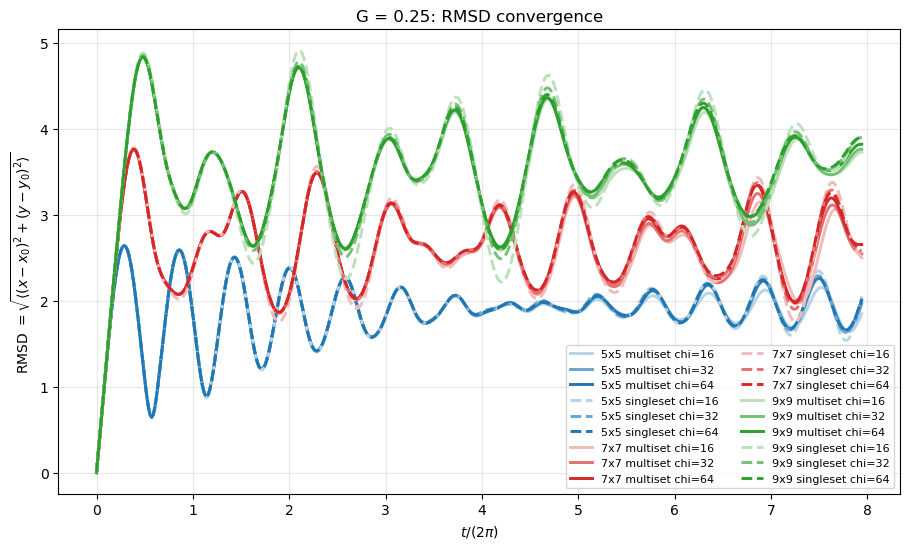

,coupling,size,method,bond_dim,path
0,G0.25,5x5,multiset,16,G0.25/Holstein_2D55/multiset/H55_2D_m16.npz
1,G0.25,5x5,multiset,32,G0.25/Holstein_2D55/multiset/H55_2D_m32.npz
2,G0.25,5x5,multiset,64,G0.25/Holstein_2D55/multiset/H55_2D_m64.npz
3,G0.25,5x5,singleset,16,G0.25/Holstein_2D55/singleset/H55_2D_s16.npz
4,G0.25,5x5,singleset,32,G0.25/Holstein_2D55/singleset/H55_2D_s32.npz
5,G0.25,5x5,singleset,64,G0.25/Holstein_2D55/singleset/H55_2D_s64.npz
6,G0.25,7x7,multiset,16,G0.25/Holstein_2D77/multiset/H77_2D_m16.npz
7,G0.25,7x7,multiset,32,G0.25/Holstein_2D77/multiset/H77_2D_m32.npz
8,G0.25,7x7,multiset,64,G0.25/Holstein_2D77/multiset/H77_2D_m64.npz
9,G0.25,7x7,singleset,16,G0.25/Holstein_2D77/singleset/H77_2D_s16.npz


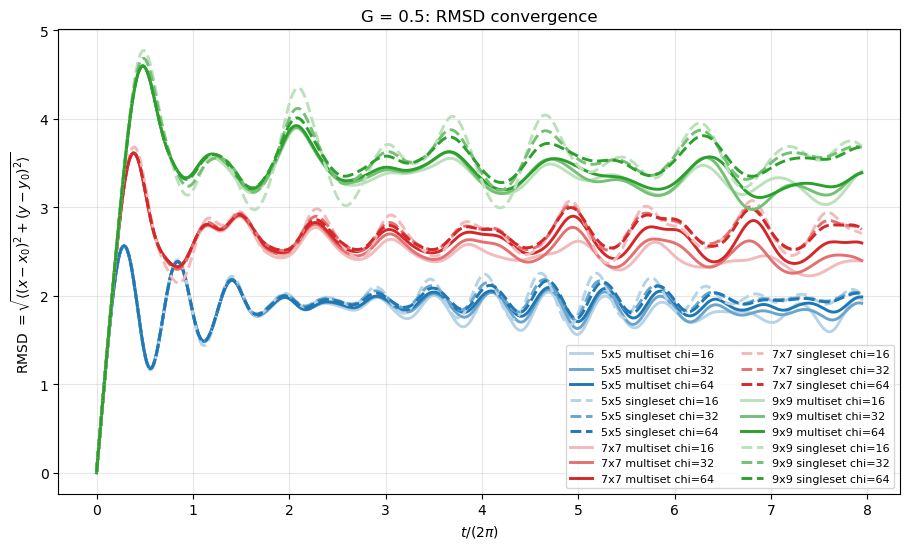

,coupling,size,method,bond_dim,path
0,G0.5,5x5,multiset,16,G0.5/Holstein_2D55/multiset/H55_2D_m16.npz
1,G0.5,5x5,multiset,32,G0.5/Holstein_2D55/multiset/H55_2D_m32.npz
2,G0.5,5x5,multiset,64,G0.5/Holstein_2D55/multiset/H55_2D_m64.npz
3,G0.5,5x5,singleset,16,G0.5/Holstein_2D55/singleset/H55_2D_s16.npz
4,G0.5,5x5,singleset,32,G0.5/Holstein_2D55/singleset/H55_2D_s32.npz
5,G0.5,5x5,singleset,64,G0.5/Holstein_2D55/singleset/H55_2D_s64.npz
6,G0.5,7x7,multiset,16,G0.5/Holstein_2D77/multiset/H77_2D_m16.npz
7,G0.5,7x7,multiset,32,G0.5/Holstein_2D77/multiset/H77_2D_m32.npz
8,G0.5,7x7,multiset,64,G0.5/Holstein_2D77/multiset/H77_2D_m64.npz
9,G0.5,7x7,singleset,16,G0.5/Holstein_2D77/singleset/H77_2D_s16.npz


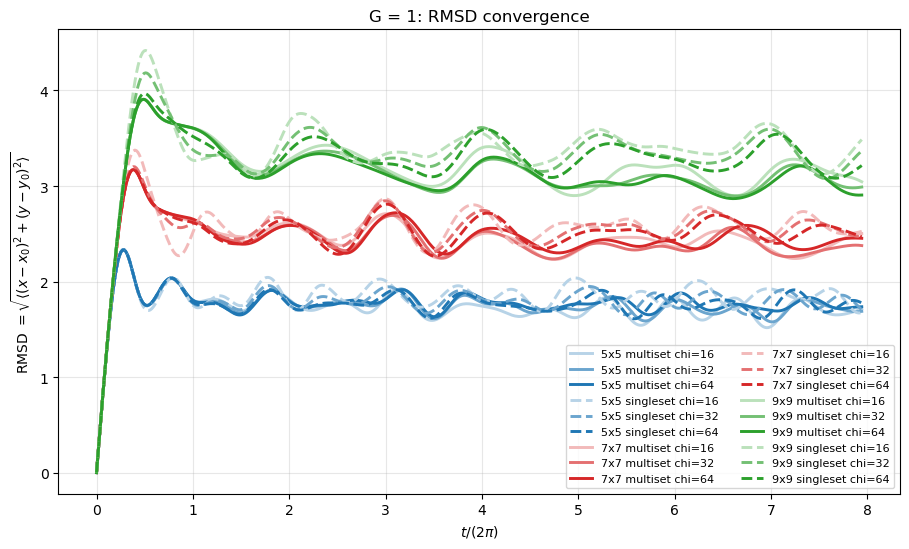

,coupling,size,method,bond_dim,path
0,G1,5x5,multiset,16,G1/Holstein_2D55/multiset/H55_2D_m16.npz
1,G1,5x5,multiset,32,G1/Holstein_2D55/multiset/H55_2D_m32.npz
2,G1,5x5,multiset,64,G1/Holstein_2D55/multiset/H55_2D_m64.npz
3,G1,5x5,singleset,16,G1/Holstein_2D55/singleset/H55_2D_s16.npz
4,G1,5x5,singleset,32,G1/Holstein_2D55/singleset/H55_2D_s32.npz
5,G1,5x5,singleset,64,G1/Holstein_2D55/singleset/H55_2D_s64.npz
6,G1,7x7,multiset,16,G1/Holstein_2D77/multiset/H77_2D_m16.npz
7,G1,7x7,multiset,32,G1/Holstein_2D77/multiset/H77_2D_m32.npz
8,G1,7x7,multiset,64,G1/Holstein_2D77/multiset/H77_2D_m64.npz
9,G1,7x7,singleset,16,G1/Holstein_2D77/singleset/H77_2D_s16.npz


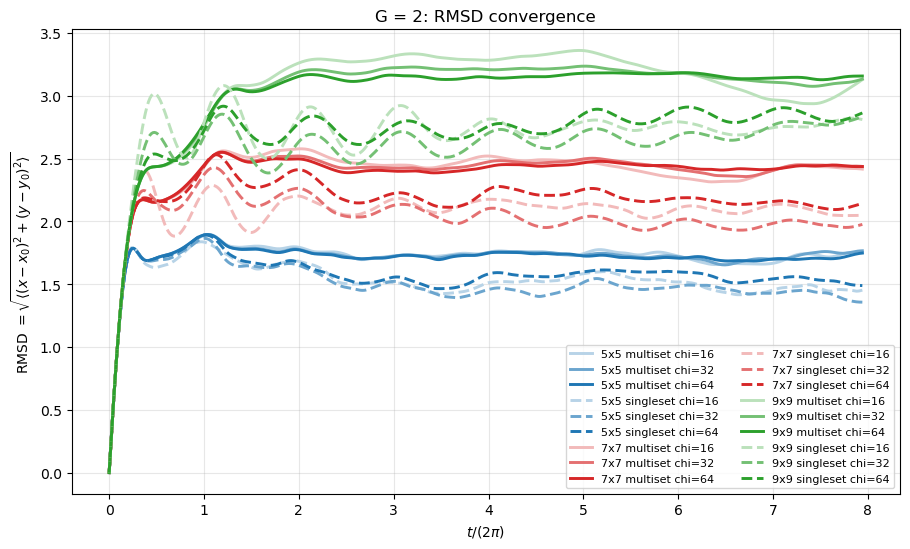

,coupling,size,method,bond_dim,path
0,G2,5x5,multiset,16,G2/Holstein_2D55/multiset/H55_2D_m16.npz
1,G2,5x5,multiset,32,G2/Holstein_2D55/multiset/H55_2D_m32.npz
2,G2,5x5,multiset,64,G2/Holstein_2D55/multiset/H55_2D_m64.npz
3,G2,5x5,singleset,16,G2/Holstein_2D55/singleset/H55_2D_s16.npz
4,G2,5x5,singleset,32,G2/Holstein_2D55/singleset/H55_2D_s32.npz
5,G2,5x5,singleset,64,G2/Holstein_2D55/singleset/H55_2D_s64.npz
6,G2,7x7,multiset,16,G2/Holstein_2D77/multiset/H77_2D_m16.npz
7,G2,7x7,multiset,32,G2/Holstein_2D77/multiset/H77_2D_m32.npz
8,G2,7x7,multiset,64,G2/Holstein_2D77/multiset/H77_2D_m64.npz
9,G2,7x7,singleset,16,G2/Holstein_2D77/singleset/H77_2D_s16.npz


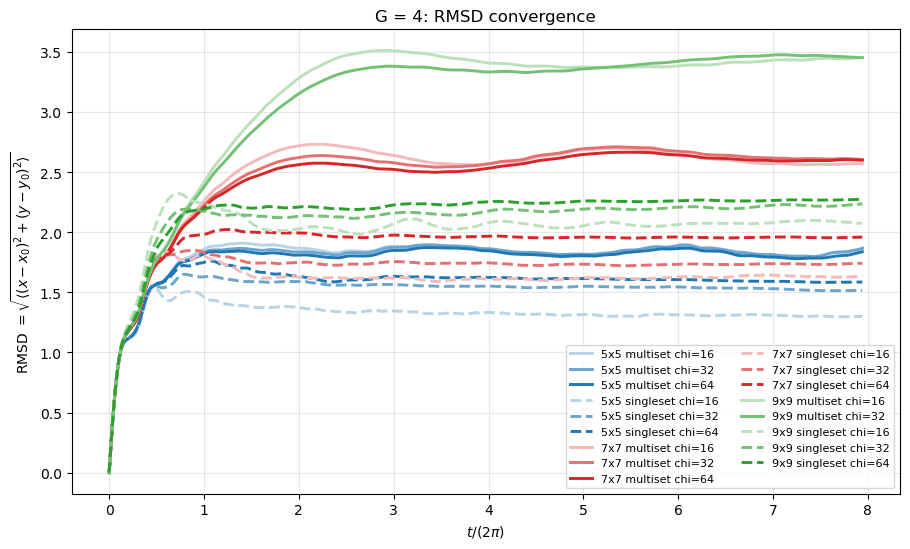

,coupling,size,method,bond_dim,path
0,G4,5x5,multiset,16,G4/Holstein_2D55/multiset/H55_2D_m16.npz
1,G4,5x5,multiset,32,G4/Holstein_2D55/multiset/H55_2D_m32.npz
2,G4,5x5,multiset,64,G4/Holstein_2D55/multiset/H55_2D_m64.npz
3,G4,5x5,singleset,16,G4/Holstein_2D55/singleset/H55_2D_s16.npz
4,G4,5x5,singleset,32,G4/Holstein_2D55/singleset/H55_2D_s32.npz
5,G4,5x5,singleset,64,G4/Holstein_2D55/singleset/H55_2D_s64.npz
6,G4,7x7,multiset,16,G4/Holstein_2D77/multiset/H77_2D_m16.npz
7,G4,7x7,multiset,32,G4/Holstein_2D77/multiset/H77_2D_m32.npz
8,G4,7x7,multiset,64,G4/Holstein_2D77/multiset/H77_2D_m64.npz
9,G4,7x7,singleset,16,G4/Holstein_2D77/singleset/H77_2D_s16.npz


In [4]:
def plot_coupling_rmsd_convergence(coupling, sizes=TARGET_SIZES, bond_dims=CONVERGENCE_BOND_DIMS):
    selected = [
        run for run in loaded_runs
        if run.meta.coupling == coupling
        and run.meta.size in sizes
        and run.meta.bond_dim in bond_dims
    ]
    if not selected:
        print(f"No RMSD data for {coupling}.")
        return pd.DataFrame()

    shades = {
        size: bond_dim_shades(SIZE_BASE_COLORS[size], {run.meta.bond_dim for run in selected if run.meta.size == size})
        for size in sizes
        if any(run.meta.size == size for run in selected)
    }
    fig, ax = plt.subplots(figsize=(9.2, 5.6))
    plotted = []

    for size in sizes:
        for method in METHODS:
            for bond_dim in sorted(bond_dims):
                candidates = [
                    run for run in selected
                    if run.meta.size == size
                    and run.meta.method == method
                    and run.meta.bond_dim == bond_dim
                ]
                if not candidates:
                    continue
                run = candidates[0]
                try:
                    rmsd = compute_rmsd_2d(run.occupations, run.meta.size)
                except ValueError as exc:
                    warnings.warn(f"skip RMSD for {run.meta.path}: {exc}")
                    continue
                n = min(len(run.time), len(rmsd))
                ax.plot(
                    plot_time(run.time[:n]),
                    rmsd[:n],
                    color=shades[size][bond_dim],
                    linestyle=method_linestyle(method),
                    linewidth=2.1,
                    label=f"{size}x{size} {method_label(method)} chi={bond_dim}",
                )
                plotted.append({
                    "coupling": coupling,
                    "size": f"{size}x{size}",
                    "method": method,
                    "bond_dim": bond_dim,
                    "path": str(run.meta.path.relative_to(BASE_DIR)),
                })

    ax.set_title(f"{COUPLING_LABELS.get(coupling, coupling)}: RMSD convergence")
    ax.set_xlabel(r"$t/(2\pi)$")
    ax.set_ylabel(r"RMSD $=\sqrt{\langle (x-x_0)^2+(y-y_0)^2\rangle}$")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    maybe_save(fig, f"{coupling}_rmsd_convergence.png")
    plt.show()
    plotted_df = pd.DataFrame(plotted)
    display(plotted_df)
    return plotted_df

# First five figures: one RMSD convergence plot for each G.
coupling_convergence_tables = {coupling: plot_coupling_rmsd_convergence(coupling) for coupling in COUPLINGS}


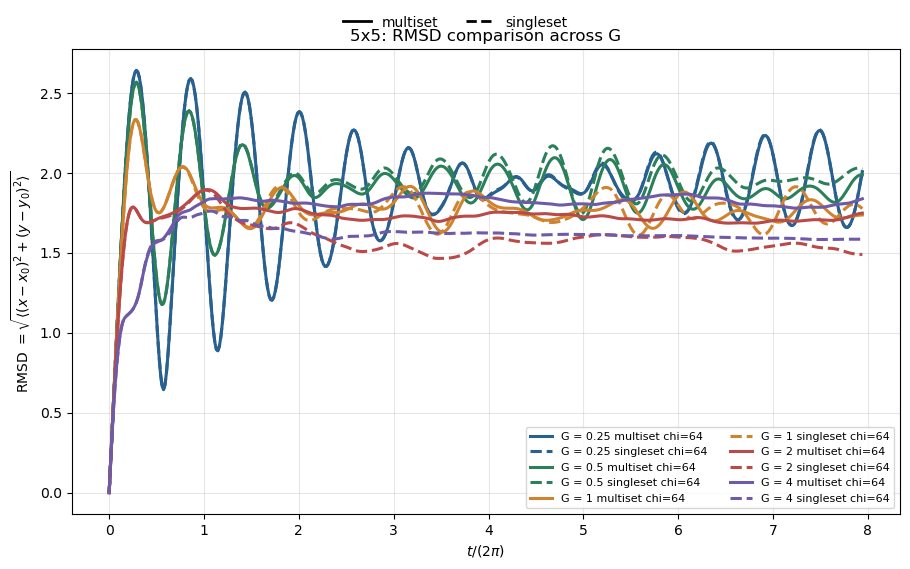

,size,coupling,method,bond_dim,path
0,5x5,G0.25,multiset,64,G0.25/Holstein_2D55/multiset/H55_2D_m64.npz
1,5x5,G0.25,singleset,64,G0.25/Holstein_2D55/singleset/H55_2D_s64.npz
2,5x5,G0.5,multiset,64,G0.5/Holstein_2D55/multiset/H55_2D_m64.npz
3,5x5,G0.5,singleset,64,G0.5/Holstein_2D55/singleset/H55_2D_s64.npz
4,5x5,G1,multiset,64,G1/Holstein_2D55/multiset/H55_2D_m64.npz
5,5x5,G1,singleset,64,G1/Holstein_2D55/singleset/H55_2D_s64.npz
6,5x5,G2,multiset,64,G2/Holstein_2D55/multiset/H55_2D_m64.npz
7,5x5,G2,singleset,64,G2/Holstein_2D55/singleset/H55_2D_s64.npz
8,5x5,G4,multiset,64,G4/Holstein_2D55/multiset/H55_2D_m64.npz
9,5x5,G4,singleset,64,G4/Holstein_2D55/singleset/H55_2D_s64.npz


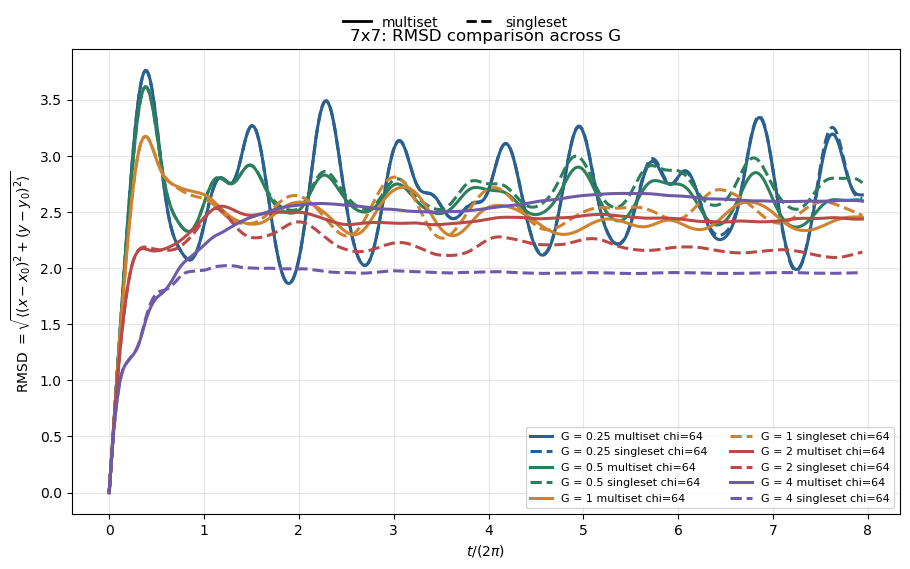

,size,coupling,method,bond_dim,path
0,7x7,G0.25,multiset,64,G0.25/Holstein_2D77/multiset/H77_2D_m64.npz
1,7x7,G0.25,singleset,64,G0.25/Holstein_2D77/singleset/H77_2D_s64.npz
2,7x7,G0.5,multiset,64,G0.5/Holstein_2D77/multiset/H77_2D_m64.npz
3,7x7,G0.5,singleset,64,G0.5/Holstein_2D77/singleset/H77_2D_s64.npz
4,7x7,G1,multiset,64,G1/Holstein_2D77/multiset/H77_2D_m64.npz
5,7x7,G1,singleset,64,G1/Holstein_2D77/singleset/H77_2D_s64.npz
6,7x7,G2,multiset,64,G2/Holstein_2D77/multiset/H77_2D_m64.npz
7,7x7,G2,singleset,64,G2/Holstein_2D77/singleset/H77_2D_s64.npz
8,7x7,G4,multiset,64,G4/Holstein_2D77/multiset/H77_2D_m64.npz
9,7x7,G4,singleset,64,G4/Holstein_2D77/singleset/H77_2D_s64.npz


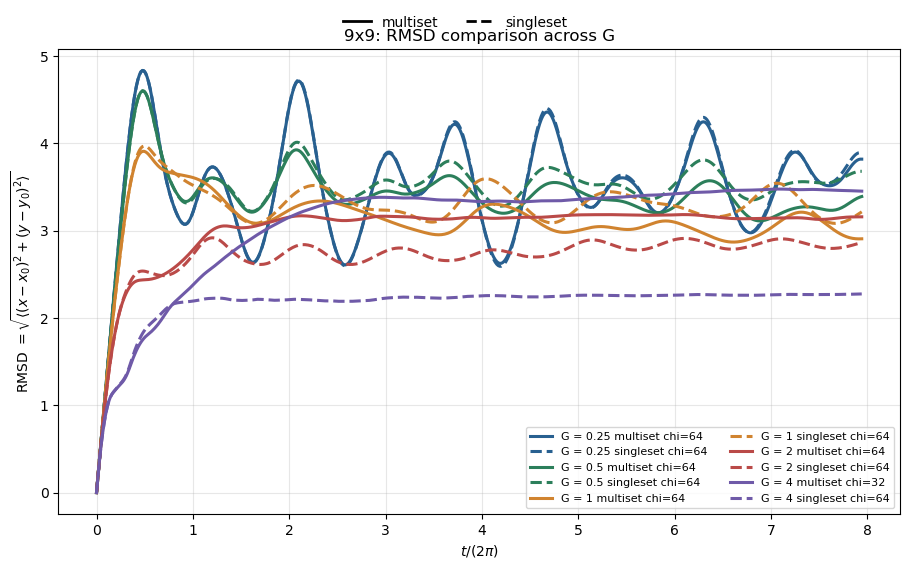

,size,coupling,method,bond_dim,path
0,9x9,G0.25,multiset,64,G0.25/Holstein_2D99/multiset/H99_2D_m64.npz
1,9x9,G0.25,singleset,64,G0.25/Holstein_2D99/singleset/H99_2D_s64.npz
2,9x9,G0.5,multiset,64,G0.5/Holstein_2D99/multiset/H99_2D_m64.npz
3,9x9,G0.5,singleset,64,G0.5/Holstein_2D99/singleset/H99_2D_s64.npz
4,9x9,G1,multiset,64,G1/Holstein_2D99/multiset/H99_2D_m64.npz
5,9x9,G1,singleset,64,G1/Holstein_2D99/singleset/H99_2D_s64.npz
6,9x9,G2,multiset,64,G2/Holstein_2D99/multiset/H99_2D_m64.npz
7,9x9,G2,singleset,64,G2/Holstein_2D99/singleset/H99_2D_s64.npz
8,9x9,G4,multiset,32,G4/Holstein_2D99/multiset/H99_2D_m32.npz
9,9x9,G4,singleset,64,G4/Holstein_2D99/singleset/H99_2D_s64.npz


In [5]:
def plot_size_rmsd_by_g(size, use_largest_bond_dim=True, bond_dim=None):
    size_records = [meta for meta in all_records if meta.size == size]
    if use_largest_bond_dim:
        size_records = select_largest_bond_dim(size_records)
    elif bond_dim is not None:
        size_records = [meta for meta in size_records if meta.bond_dim == bond_dim]

    runs = [
        run for run in (load_run(meta) for meta in size_records)
        if run is not None and run.time is not None and run.occupations is not None
    ]
    if not runs:
        print(f"No RMSD data for {size}x{size}.")
        return pd.DataFrame()

    fig, ax = plt.subplots(figsize=(9.2, 5.6))
    plotted = []
    for coupling in COUPLINGS:
        for method in METHODS:
            candidates = [run for run in runs if run.meta.coupling == coupling and run.meta.method == method]
            if not candidates:
                continue
            run = candidates[0]
            try:
                rmsd = compute_rmsd_2d(run.occupations, run.meta.size)
            except ValueError as exc:
                warnings.warn(f"skip RMSD for {run.meta.path}: {exc}")
                continue
            n = min(len(run.time), len(rmsd))
            ax.plot(
                plot_time(run.time[:n]),
                rmsd[:n],
                color=COUPLING_BASE_COLORS[coupling],
                linestyle=method_linestyle(method),
                linewidth=2.2,
                label=f"{COUPLING_LABELS[coupling]} {method_label(method)} chi={run.meta.bond_dim}",
            )
            plotted.append({
                "size": f"{size}x{size}",
                "coupling": coupling,
                "method": method,
                "bond_dim": run.meta.bond_dim,
                "path": str(run.meta.path.relative_to(BASE_DIR)),
            })

    ax.set_title(f"{size}x{size}: RMSD comparison across G")
    ax.set_xlabel(r"$t/(2\pi)$")
    ax.set_ylabel(r"RMSD $=\sqrt{\langle (x-x_0)^2+(y-y_0)^2\rangle}$")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)
    handles = [
        Line2D([0], [0], color="black", lw=2, linestyle="-", label="multiset"),
        Line2D([0], [0], color="black", lw=2, linestyle="--", label="singleset"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
    fig.tight_layout()
    maybe_save(fig, f"H{size}{size}_rmsd_by_G.png")
    plt.show()
    plotted_df = pd.DataFrame(plotted)
    display(plotted_df)
    return plotted_df

# Last three figures: one G-comparison RMSD plot for each lattice size.
size_comparison_tables = {size: plot_size_rmsd_by_g(size) for size in TARGET_SIZES}


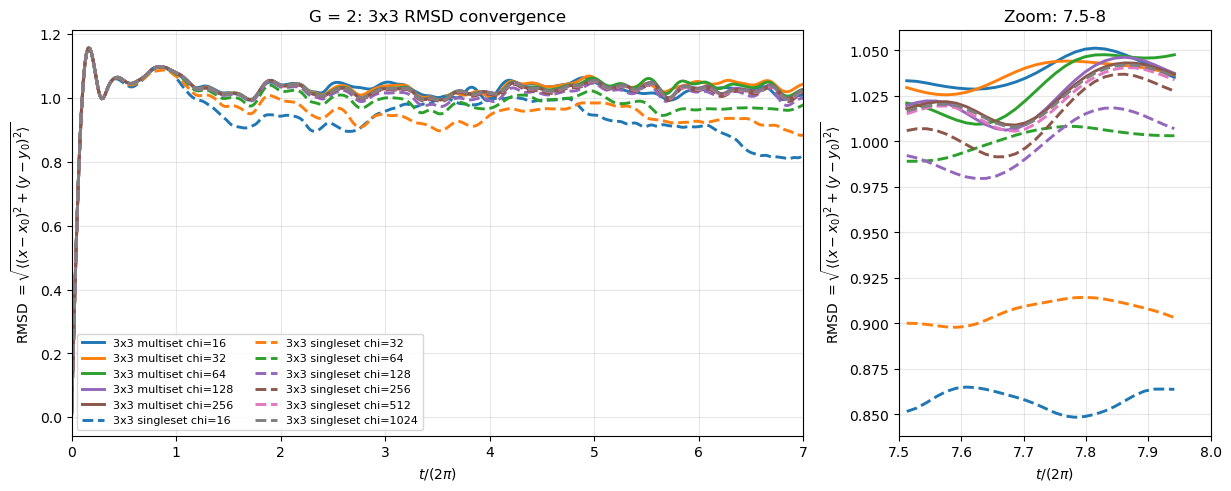

,coupling,size,method,bond_dim,path
0,G2,3x3,multiset,16,G2/Holstein_2D33/multiset/H33_2D_m16.npz
1,G2,3x3,multiset,32,G2/Holstein_2D33/multiset/H33_2D_m32.npz
2,G2,3x3,multiset,64,G2/Holstein_2D33/multiset/H33_2D_m64.npz
3,G2,3x3,multiset,128,G2/Holstein_2D33/multiset/H33_2D_m128.npz
4,G2,3x3,multiset,256,G2/Holstein_2D33/multiset/H33_2D_m256.npz
5,G2,3x3,singleset,16,G2/Holstein_2D33/singleset/H33_2D_s16.npz
6,G2,3x3,singleset,32,G2/Holstein_2D33/singleset/H33_2D_s32.npz
7,G2,3x3,singleset,64,G2/Holstein_2D33/singleset/H33_2D_s64.npz
8,G2,3x3,singleset,128,G2/Holstein_2D33/singleset/H33_2D_s128.npz
9,G2,3x3,singleset,256,G2/Holstein_2D33/singleset/H33_2D_s256.npz


In [11]:
# Extra figure: G2 3x3 RMSD convergence only.
zoom_xlim_33 = (7.5, 8.0)
records_33 = [
    meta for meta in discover_run_files(BASE_DIR, sizes=[3], bond_dims=None)
    if meta.coupling == "G2" and "Holstein_2D33" in meta.path.parts
]
runs_33 = [
    run for run in (load_run(meta) for meta in records_33)
    if run is not None and run.time is not None and run.occupations is not None
]
available_bond_dims_33 = sorted({run.meta.bond_dim for run in runs_33 if run.meta.bond_dim is not None})

if not runs_33:
    print("No G2 Holstein_2D33 RMSD data found.")
    holstein_2d33_table = pd.DataFrame()
else:
    bond_dim_palette = {
        16: "#1f77b4",
        32: "#ff7f0e",
        64: "#2ca02c",
        128: "#9467bd",
        256: "#8c564b",
        512: "#e377c2",
        1024: "#7f7f7f",
    }
    fallback_cmap = plt.get_cmap("tab10")
    bond_dim_colors = {
        bond_dim: bond_dim_palette.get(bond_dim, to_hex(fallback_cmap(i % fallback_cmap.N)))
        for i, bond_dim in enumerate(available_bond_dims_33)
    }
    fig, (ax, ax_zoom) = plt.subplots(
        1,
        2,
        figsize=(12.2, 4.8),
        gridspec_kw={"width_ratios": [2.35, 1.0]},
        constrained_layout=True,
    )
    plotted = []

    for method in METHODS:
        for bond_dim in available_bond_dims_33:
            candidates = [
                run for run in runs_33
                if run.meta.method == method and run.meta.bond_dim == bond_dim
            ]
            if not candidates:
                continue
            run = candidates[0]
            try:
                rmsd = compute_rmsd_2d(run.occupations, run.meta.size)
            except ValueError as exc:
                warnings.warn(f"skip RMSD for {run.meta.path}: {exc}")
                continue
            n = min(len(run.time), len(rmsd))
            t = plot_time(run.time[:n])
            y = rmsd[:n]
            kwargs = {
                "color": bond_dim_colors[bond_dim],
                "linestyle": method_linestyle(method),
                "linewidth": 2.1,
            }
            label = f"3x3 {method_label(method)} chi={bond_dim}"
            ax.plot(t, y, label=label, **kwargs)

            zoom_mask = (t >= zoom_xlim_33[0]) & (t <= zoom_xlim_33[1])
            ax_zoom.plot(t[zoom_mask], y[zoom_mask], **kwargs)

            plotted.append({
                "coupling": run.meta.coupling,
                "size": "3x3",
                "method": method,
                "bond_dim": bond_dim,
                "path": str(run.meta.path.relative_to(BASE_DIR)),
            })

    for axis in (ax, ax_zoom):
        axis.set_xlabel(r"$t/(2\pi)$")
        axis.set_ylabel(r"RMSD $=\sqrt{\langle (x-x_0)^2+(y-y_0)^2\rangle}$")
        axis.grid(True, alpha=0.3)

    ax.set_title("G = 2: 3x3 RMSD convergence")
    ax.set_xlim(left=0,right=7)
    ax.legend(fontsize=8, ncol=2)

    ax_zoom.set_title(f"Zoom: {zoom_xlim_33[0]:g}-{zoom_xlim_33[1]:g}")
    ax_zoom.set_xlim(*zoom_xlim_33)

    maybe_save(fig, "G2_H33_rmsd_convergence.png")
    plt.show()
    holstein_2d33_table = pd.DataFrame(plotted)
    display(holstein_2d33_table)
